# BodyShapeGPT — Keyword ↔ Beta Parameter Correlation Analysis

This notebook finds which descriptive words correlate most strongly with each of the 10 SMPL shape parameters (betas), and derives normalized weight scores to guide training.

## 1. Import Libraries & Load Dataset

In [13]:
import json
import ast
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ── Load dataset ──────────────────────────────────────────────────────────────
# Run from repo root, or adjust the path below
DATASET_PATH = "../BodyShapeGPT_dataset.jsonl"

data = []
with open(DATASET_PATH) as f:
    for line in f:
        data.append(json.loads(line))

descriptions = [d["description"] for d in data]
betas = np.array([ast.literal_eval(d["shape_params"]) for d in data])  # (N, 10)

beta_cols = [f"beta_{i}" for i in range(10)]
df_betas = pd.DataFrame(betas, columns=beta_cols)

print(f"Samples : {len(data)}")
print(f"Beta shape: {betas.shape}")
df_betas.describe().round(3)

Samples : 21000
Beta shape: (21000, 10)


,beta_0,beta_1,beta_2,beta_3,beta_4,beta_5,beta_6,beta_7,beta_8,beta_9
count,21000.000,21000.000,21000.000,21000.000,21000.000,21000.000,21000.000,21000.000,21000.000,21000.000
mean,0.005,0.007,-0.002,0.006,-0.019,-0.011,0.010,0.005,-0.004,0.008
std,1.393,1.399,1.413,1.413,1.405,1.406,1.399,1.400,1.403,1.406
min,-5.519,-5.572,-5.866,-4.983,-6.025,-5.310,-5.776,-6.049,-5.122,-5.219
25%,-0.938,-0.929,-0.940,-0.946,-0.965,-0.950,-0.923,-0.931,-0.949,-0.934
50%,-0.005,0.020,-0.010,0.003,-0.009,-0.010,0.009,0.004,-0.002,-0.016
75%,0.948,0.962,0.946,0.947,0.922,0.936,0.944,0.942,0.942,0.952
max,5.753,5.705,5.459,5.795,6.810,5.529,5.846,5.547,5.728,5.408


## 2. Beta Parameter Statistics & Distributions

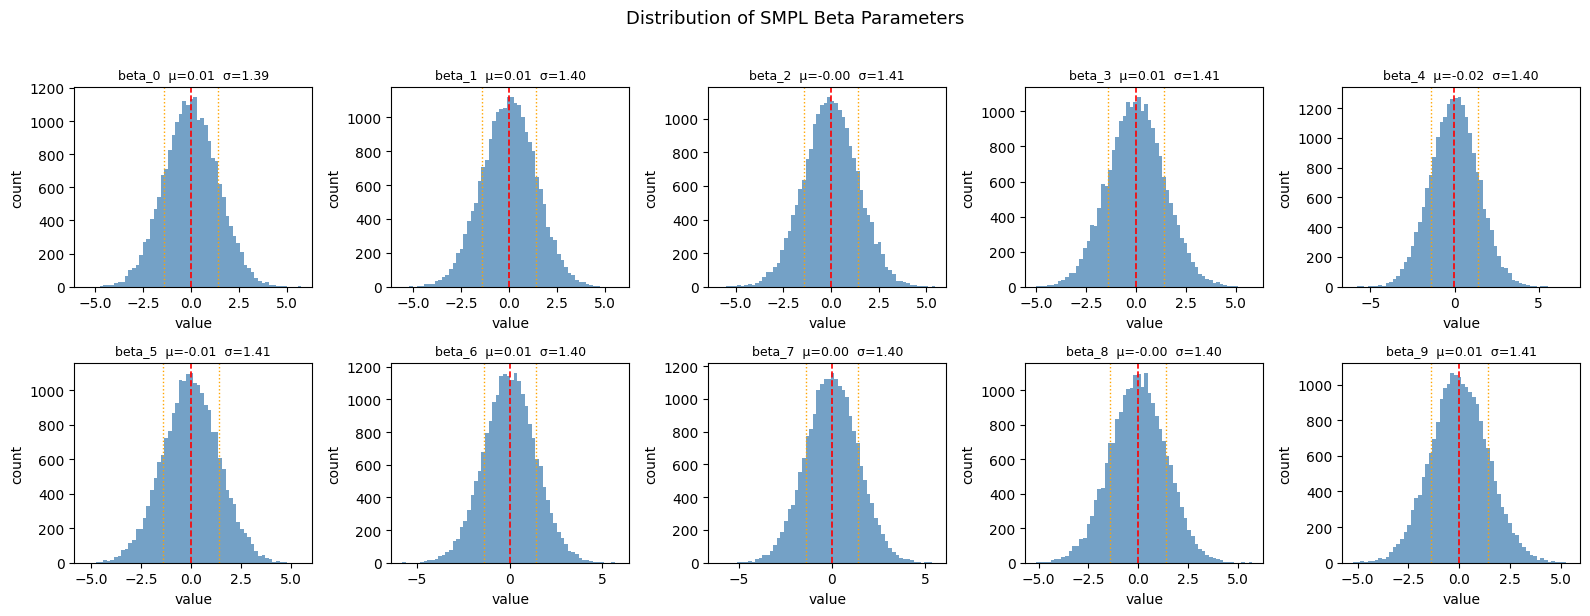

,mean,std
beta_0,0.005,1.393
beta_1,0.007,1.399
beta_2,-0.002,1.413
beta_3,0.006,1.413
beta_4,-0.019,1.405
beta_5,-0.011,1.406
beta_6,0.010,1.399
beta_7,0.005,1.400
beta_8,-0.004,1.403
beta_9,0.008,1.406


In [14]:
means = betas.mean(axis=0)
stds  = betas.std(axis=0)

fig, axes = plt.subplots(2, 5, figsize=(16, 6))
axes = axes.flatten()
for i in range(10):
    ax = axes[i]
    ax.hist(betas[:, i], bins=60, color="steelblue", alpha=0.75, edgecolor="none")
    ax.axvline(means[i], color="red",    linestyle="--", linewidth=1.2, label=f"μ={means[i]:.2f}")
    ax.axvline(means[i] + stds[i], color="orange", linestyle=":", linewidth=1)
    ax.axvline(means[i] - stds[i], color="orange", linestyle=":", linewidth=1, label=f"σ={stds[i]:.2f}")
    ax.set_title(f"beta_{i}  μ={means[i]:.2f}  σ={stds[i]:.2f}", fontsize=9)
    ax.set_xlabel("value")
    ax.set_ylabel("count")

plt.suptitle("Distribution of SMPL Beta Parameters", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Summary table
pd.DataFrame({"mean": means, "std": stds}, index=beta_cols).round(3)

## 3. Keyword Presence Matrix

Define keywords grouped by body region, build a binary presence matrix, and filter out rare terms.

In [15]:
KEYWORDS = {
    # ── Height ─────────────────────────────────────────────────────────────
    "height": ["tall", "short", "average height", "petite", "compact", "towering"],

    # ── Neck ───────────────────────────────────────────────────────────────
    "neck": ["tall neck", "short neck", "long neck", "slender neck"],

    # ── Arms ───────────────────────────────────────────────────────────────
    "arms_length": ["long arms", "short arms"],
    "arms_thickness": ["thick arms", "thin arms", "spindly arms", "sturdy arms", "robust arms"],

    # ── Legs ───────────────────────────────────────────────────────────────
    "legs_length": ["long legs", "short legs"],
    "legs_thickness": ["thick legs", "thin legs", "sturdy legs", "slender legs"],

    # ── Shoulders ──────────────────────────────────────────────────────────
    "shoulders": ["broad shoulders", "narrow shoulders", "wide shoulders"],

    # ── Hips ───────────────────────────────────────────────────────────────
    # NOTE: dataset uses "broad hip" / "narrow hip" — NOT "wide hips"
    "hips": ["broad hip", "narrow hip", "expansive hips", "slim hips"],

    # ── Body Mass ──────────────────────────────────────────────────────────
    "body_mass": ["lot of body mass", "low body mass", "meager body mass",
                  "ample body mass", "muscular", "slender"],

    # ── Bust & Waist Thickness ─────────────────────────────────────────────
    "bust": ["thick bust", "thin bust", "ample chest", "slim torso"],
    "waist": ["thick waist", "thin waist", "expansive waist", "slim waist"],
}

# Flat list, preserving group ordering
all_keywords = [kw for group in KEYWORDS.values() for kw in group]

# ── Binary presence matrix ─────────────────────────────────────────────────
MIN_COUNT = 20

presence_dict = {}
for kw in all_keywords:
    vec = np.array([1.0 if kw.lower() in d.lower() else 0.0 for d in descriptions])
    if vec.sum() >= MIN_COUNT:
        presence_dict[kw] = vec

kept_keywords = list(presence_dict.keys())
presence_matrix = np.stack([presence_dict[kw] for kw in kept_keywords], axis=1)  # (N, K)

# Frequency table
freq = pd.Series({kw: int(presence_dict[kw].sum()) for kw in kept_keywords}, name="count")
freq_df = freq.reset_index().rename(columns={"index": "keyword"}).sort_values("count", ascending=False)
print(f"Keywords kept (count ≥ {MIN_COUNT}): {len(kept_keywords)}")
freq_df.style.bar(subset=["count"], color="#5fba7d")

Keywords kept (count ≥ 20): 44


,keyword,count
2,average height,7417
1,short,6946
0,tall,4413
35,slender,2977
23,broad shoulders,2801
26,broad hip,2668
19,thick legs,2642
17,long legs,2632
18,short legs,2626
13,thin arms,2615


## 4. Pearson Correlation Analysis (Keyword vs Beta)

Compute point-biserial r and p-value for every (keyword, beta) pair. Significant = p < 0.05.

In [16]:
records = []
for kw in kept_keywords:
    vec = presence_dict[kw]
    for b_idx in range(10):
        r, p = stats.pointbiserialr(vec, betas[:, b_idx])
        records.append({
            "keyword":     kw,
            "beta_index":  b_idx,
            "beta":        f"beta_{b_idx}",
            "r":           round(r, 5),
            "p_value":     round(p, 6),
            "abs_r":       round(abs(r), 5),
            "significant": p < 0.05,
        })

corr_df = pd.DataFrame(records)

# Pivot table: keywords × betas
r_pivot = corr_df.pivot(index="keyword", columns="beta", values="r").round(4)

print(f"Total (keyword, beta) pairs: {len(corr_df)}")
print(f"Significant (p<0.05): {corr_df['significant'].sum()}")
corr_df.head(20)

Total (keyword, beta) pairs: 440
Significant (p<0.05): 291


,keyword,beta_index,beta,r,p_value,abs_r,significant
0,tall,0,beta_0,0.49349,0.000000,0.49349,True
1,tall,1,beta_1,0.03012,0.000013,0.03012,True
2,tall,2,beta_2,0.04597,0.000000,0.04597,True
3,tall,3,beta_3,-0.01394,0.043302,0.01394,True
4,tall,4,beta_4,0.05104,0.000000,0.05104,True
5,tall,5,beta_5,0.04330,0.000000,0.04330,True
6,tall,6,beta_6,-0.01431,0.038085,0.01431,True
7,tall,7,beta_7,-0.03097,0.000007,0.03097,True
8,tall,8,beta_8,-0.01846,0.007455,0.01846,True
9,tall,9,beta_9,0.01618,0.019072,0.01618,True


## 5. Correlation Heatmap Visualization

Two heatmaps: (a) all correlations, (b) significant-only (non-significant cells are blanked).

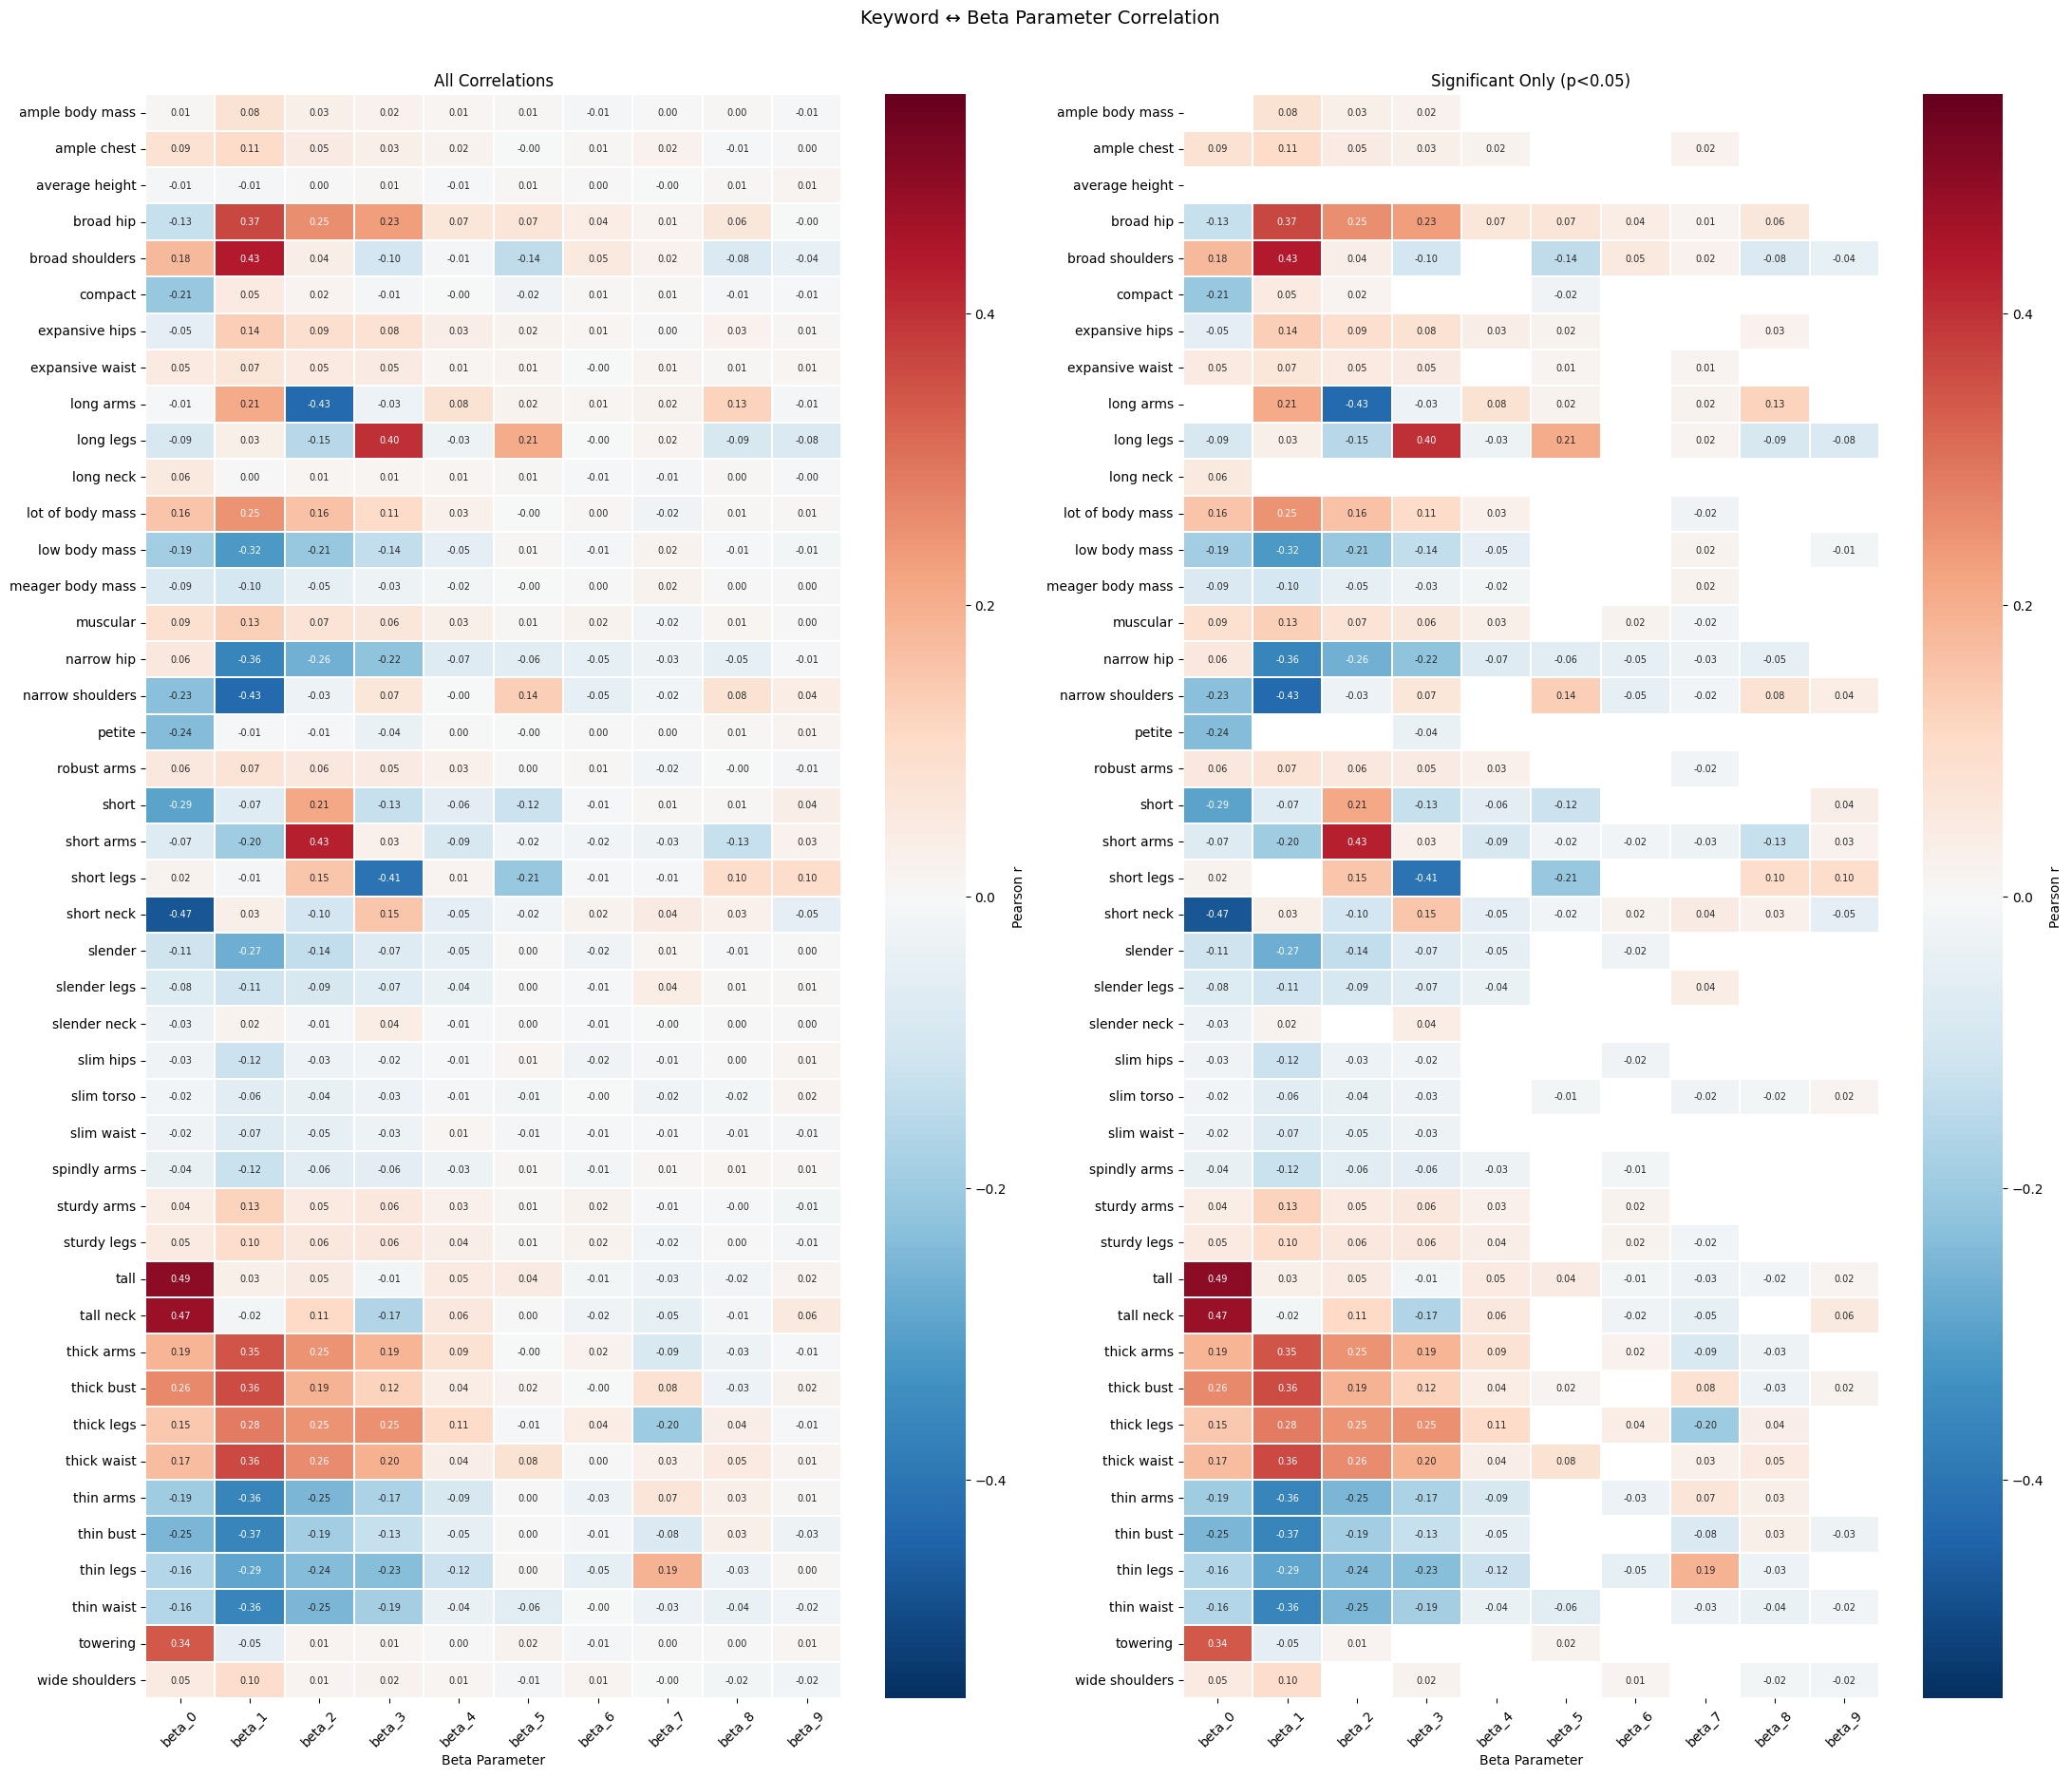

In [17]:
p_pivot = corr_df.pivot(index="keyword", columns="beta", values="p_value")

# Reorder columns
ordered_cols = [f"beta_{i}" for i in range(10)]
r_mat = r_pivot[ordered_cols]
p_mat = p_pivot[ordered_cols]

fig, axes = plt.subplots(1, 2, figsize=(22, max(8, len(kept_keywords) * 0.42)))

for ax, (title, mat, mask) in zip(axes, [
    ("All Correlations",        r_mat, None),
    ("Significant Only (p<0.05)", r_mat, p_mat >= 0.05),
]):
    sns.heatmap(
        mat,
        mask=mask,
        cmap="RdBu_r",
        center=0,
        vmin=-0.55, vmax=0.55,
        annot=True, fmt=".2f",
        annot_kws={"size": 7},
        linewidths=0.3,
        ax=ax,
        cbar_kws={"label": "Pearson r"},
    )
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Beta Parameter")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Keyword ↔ Beta Parameter Correlation", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 6. Top Keywords per Beta Parameter

For each beta, show the 5 most positively and 5 most negatively correlated keywords.

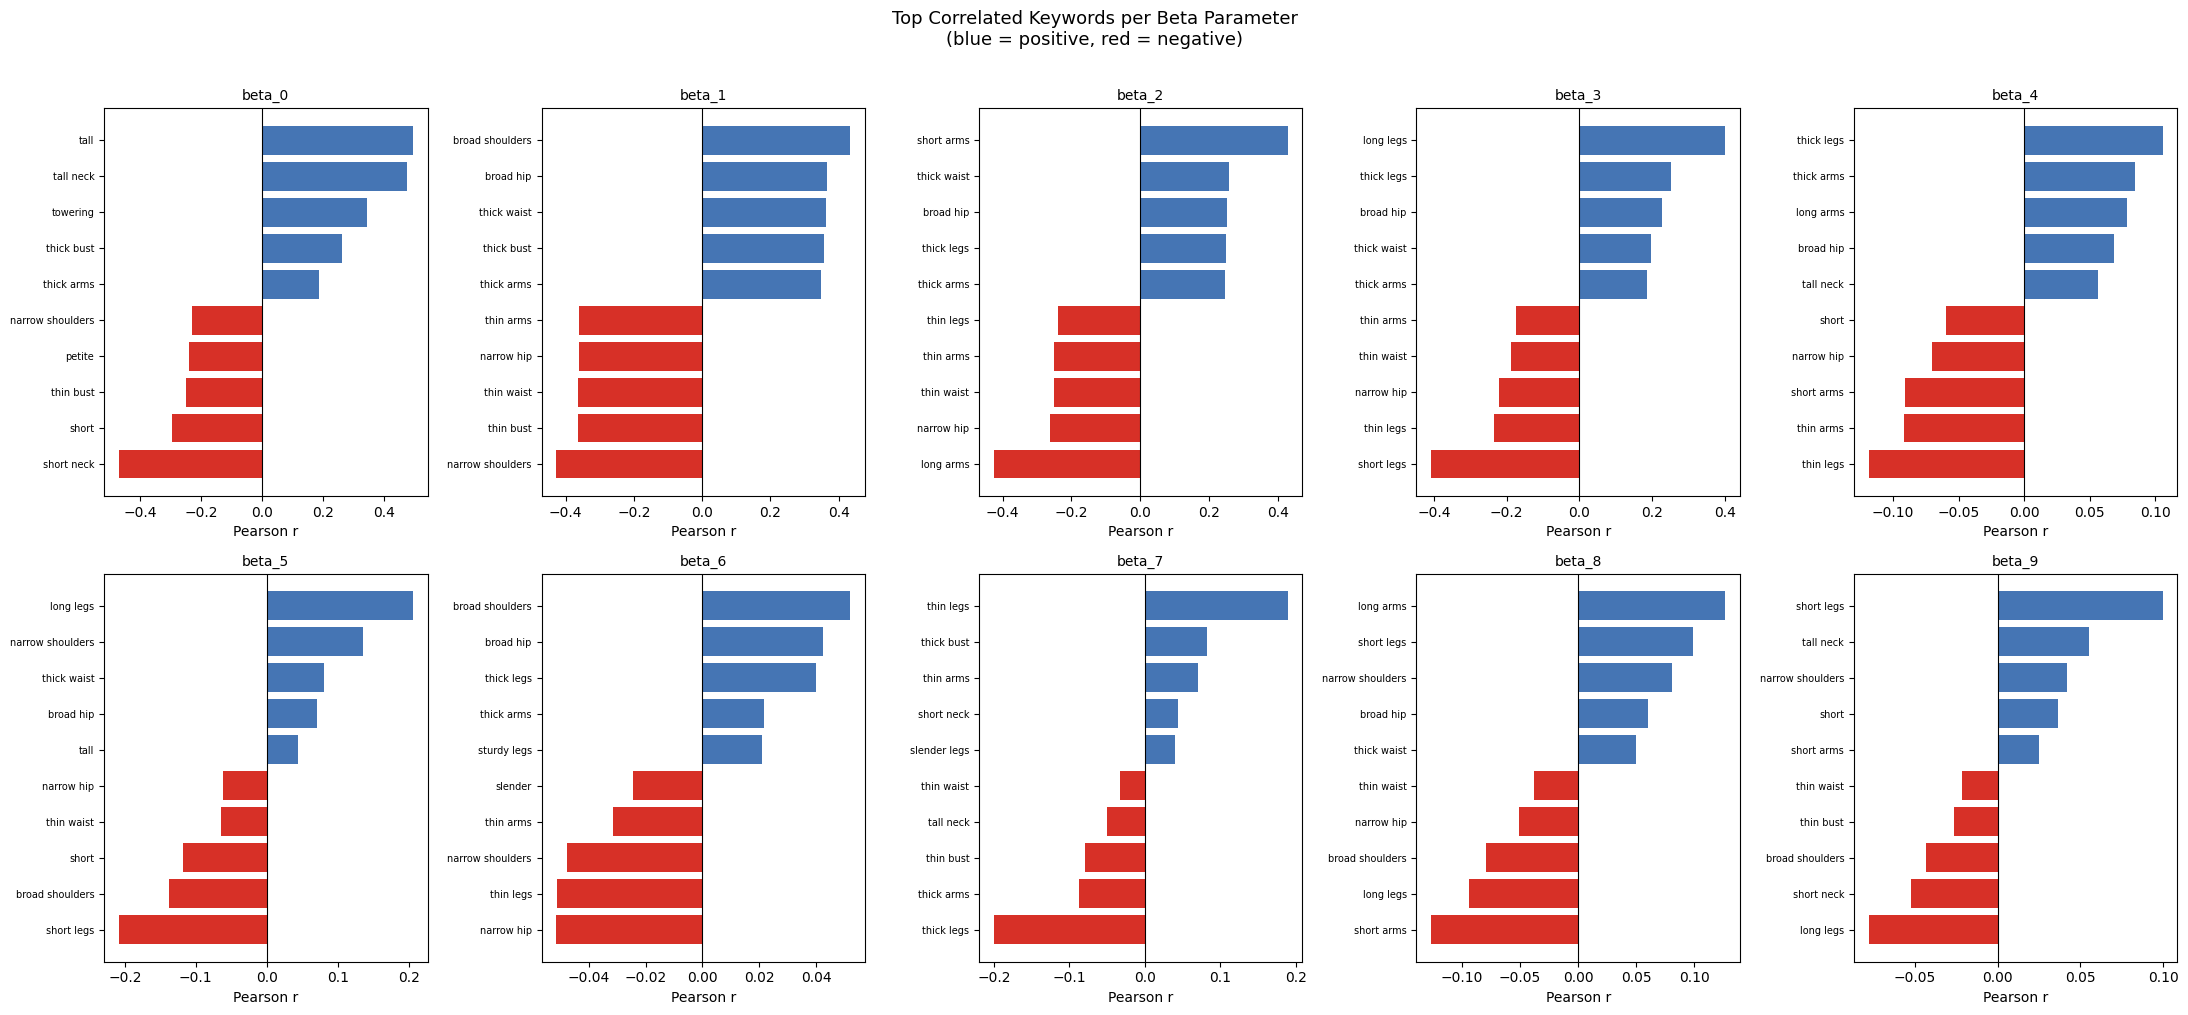

In [18]:
TOP_N = 5
sig_df = corr_df[corr_df["significant"]]

fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

for b_idx in range(10):
    ax = axes[b_idx]
    sub = sig_df[sig_df["beta_index"] == b_idx].sort_values("r")

    top_pos = sub.nlargest(TOP_N, "r")
    top_neg = sub.nsmallest(TOP_N, "r")
    plot_df = pd.concat([top_neg, top_pos]).drop_duplicates("keyword")
    plot_df = plot_df.sort_values("r")

    colors = ["#d73027" if r < 0 else "#4575b4" for r in plot_df["r"]]
    ax.barh(plot_df["keyword"], plot_df["r"], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"beta_{b_idx}", fontsize=10)
    ax.set_xlabel("Pearson r")
    ax.tick_params(axis="y", labelsize=7)

plt.suptitle("Top Correlated Keywords per Beta Parameter\n(blue = positive, red = negative)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [19]:
# Tabular view: best single keyword per beta (highest |r|, significant)
print("=== Best keyword per beta (highest |r|, p < 0.05) ===\n")
summary_rows = []
for b_idx in range(10):
    sub = sig_df[sig_df["beta_index"] == b_idx]
    if sub.empty:
        summary_rows.append({"beta": f"beta_{b_idx}", "best_keyword": "—", "r": np.nan})
        continue
    best = sub.loc[sub["abs_r"].idxmax()]
    summary_rows.append({"beta": f"beta_{b_idx}", "best_keyword": best["keyword"], "r": best["r"]})

pd.DataFrame(summary_rows).set_index("beta")

=== Best keyword per beta (highest |r|, p < 0.05) ===



,best_keyword,r
beta,,
beta_0,tall,0.49349
beta_1,broad shoulders,0.43425
beta_2,short arms,0.42935
beta_3,short legs,-0.40720
beta_4,thin legs,-0.11864
beta_5,short legs,-0.20847
beta_6,broad shoulders,0.05196
beta_7,thick legs,-0.20013
beta_8,long arms,0.12680


## 6b. Single Best Correlation Value per Beta

For training, pick **one r value per beta** — the keyword with the highest absolute Pearson r that is also statistically significant (p < 0.05).

In [20]:
# For each beta, find the single keyword with the highest |r| (significant only)
best_per_beta = []
for b_idx in range(10):
    sub = sig_df[sig_df["beta_index"] == b_idx]
    if sub.empty:
        best_per_beta.append({
            "beta": f"beta_{b_idx}",
            "best_keyword": "—",
            "r": 0.0,
            "abs_r": 0.0,
            "p_value": 1.0,
            "learnability": "❌ No signal",
        })
        continue
    row = sub.loc[sub["abs_r"].idxmax()]
    abs_r = row["abs_r"]
    if abs_r >= 0.40:
        label = "✅ Strong"
    elif abs_r >= 0.20:
        label = "🟡 Moderate"
    elif abs_r >= 0.10:
        label = "🟠 Weak"
    else:
        label = "❌ Very weak"
    best_per_beta.append({
        "beta": f"beta_{b_idx}",
        "best_keyword": row["keyword"],
        "r": row["r"],
        "abs_r": abs_r,
        "p_value": row["p_value"],
        "learnability": label,
    })

best_df = pd.DataFrame(best_per_beta).set_index("beta")
best_df

,best_keyword,r,abs_r,p_value,learnability
beta,,,,,
beta_0,tall,0.49349,0.49349,0.0,✅ Strong
beta_1,broad shoulders,0.43425,0.43425,0.0,✅ Strong
beta_2,short arms,0.42935,0.42935,0.0,✅ Strong
beta_3,short legs,-0.40720,0.40720,0.0,✅ Strong
beta_4,thin legs,-0.11864,0.11864,0.0,🟠 Weak
beta_5,short legs,-0.20847,0.20847,0.0,🟡 Moderate
beta_6,broad shoulders,0.05196,0.05196,0.0,❌ Very weak
beta_7,thick legs,-0.20013,0.20013,0.0,🟡 Moderate
beta_8,long arms,0.12680,0.12680,0.0,🟠 Weak


/tmp/ipykernel_12592/742198540.py:33: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12592/742198540.py:33: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12592/742198540.py:33: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12592/742198540.py:33: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/schaeffler-pte-ltd/david_ws/BodyShapeGPT/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/schaeffler-pte-ltd/david_ws/BodyShapeGPT/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s)

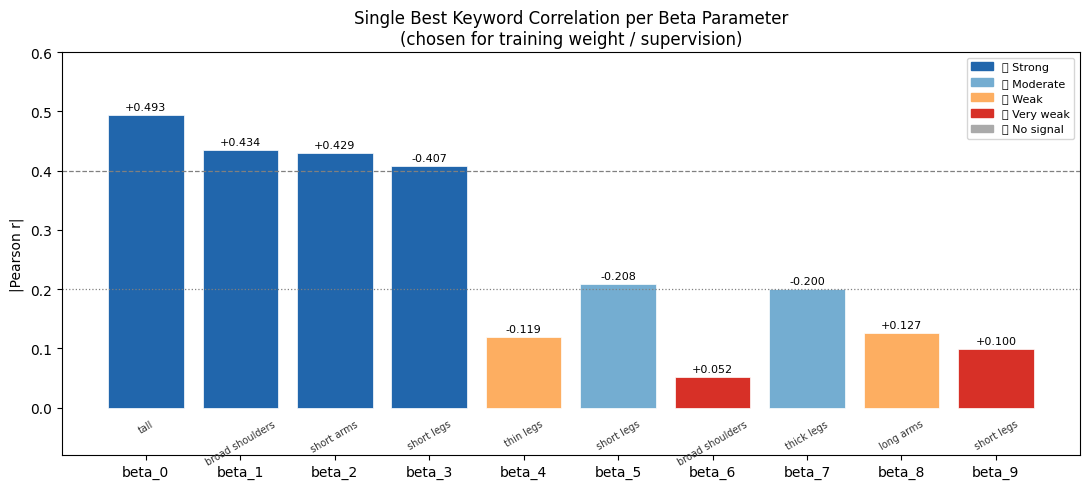

In [21]:
# Bar chart: best |r| per beta, coloured by learnability tier
color_map = {
    "✅ Strong":    "#2166ac",
    "🟡 Moderate":  "#74add1",
    "🟠 Weak":      "#fdae61",
    "❌ Very weak": "#d73027",
    "❌ No signal": "#aaaaaa",
}

fig, ax = plt.subplots(figsize=(11, 5))
for i, (beta, row) in enumerate(best_df.iterrows()):
    bar_color = color_map.get(row["learnability"], "#aaaaaa")
    ax.bar(i, row["abs_r"], color=bar_color, edgecolor="white", linewidth=0.5)
    ax.text(i, row["abs_r"] + 0.005, f'{row["r"]:+.3f}', ha="center", va="bottom", fontsize=8)
    ax.text(i, -0.018, row["best_keyword"], ha="center", va="top", fontsize=7, rotation=30, color="#333333")

# Learnability tier lines
for threshold, label, ls in [(0.40, "|r|=0.40  Strong", "--"), (0.20, "|r|=0.20  Moderate", ":")]:
    ax.axhline(threshold, color="grey", linestyle=ls, linewidth=0.9, label=label)

ax.set_xticks(range(10))
ax.set_xticklabels([f"beta_{i}" for i in range(10)])
ax.set_ylim(-0.08, 0.6)
ax.set_ylabel("|Pearson r|")
ax.set_title("Single Best Keyword Correlation per Beta Parameter\n(chosen for training weight / supervision)", fontsize=12)
ax.legend(fontsize=8, loc="upper right")

# Colour legend
from matplotlib.patches import Patch
legend_patches = [Patch(color=c, label=l) for l, c in color_map.items()]
ax.legend(handles=legend_patches, fontsize=8, loc="upper right")

plt.tight_layout()
plt.show()

## 7. Ranked Weight Candidates per Beta

Normalize `|r|` per-beta using min-max scaling → **weight score ∈ [0, 1]**.
A higher weight score means that keyword is a stronger cue for that beta — use these scores to set per-keyword loss weights or attention masks during training.

In [22]:
def minmax_scale(series):
    mn, mx = series.min(), series.max()
    if mx == mn:
        return series * 0.0
    return (series - mn) / (mx - mn)

# Per-beta min-max normalisation of |r|
weight_df = corr_df[corr_df["significant"]].copy()
weight_df["weight"] = (
    weight_df
    .groupby("beta_index")["abs_r"]
    .transform(minmax_scale)
    .round(4)
)

# Show top-5 per beta sorted by weight descending
print("=== Top-5 weight candidates per beta ===\n")
for b_idx in range(10):
    top = (
        weight_df[weight_df["beta_index"] == b_idx]
        .sort_values("weight", ascending=False)
        .head(5)[["keyword", "r", "abs_r", "weight"]]
    )
    print(f"  beta_{b_idx}:")
    print(top.to_string(index=False))
    print()

=== Top-5 weight candidates per beta ===

  beta_0:
   keyword        r   abs_r  weight
      tall  0.49349 0.49349  1.0000
 tall neck  0.47430 0.47430  0.9594
short neck -0.46997 0.46997  0.9502
  towering  0.34164 0.34164  0.6787
     short -0.29448 0.29448  0.5790

  beta_1:
         keyword        r   abs_r  weight
 broad shoulders  0.43425 0.43425  1.0000
narrow shoulders -0.42766 0.42766  0.9842
       broad hip  0.36719 0.36719  0.8396
       thin bust -0.36513 0.36513  0.8347
      thin waist -0.36490 0.36490  0.8341

  beta_2:
    keyword        r   abs_r  weight
 short arms  0.42935 0.42935  1.0000
  long arms -0.42623 0.42623  0.9925
 narrow hip -0.26338 0.26338  0.6002
thick waist  0.25966 0.25966  0.5912
  broad hip  0.25394 0.25394  0.5774

  beta_3:
   keyword        r   abs_r  weight
short legs -0.40720 0.40720  1.0000
 long legs  0.40120 0.40120  0.9847
thick legs  0.25101 0.25101  0.6028
 thin legs -0.23329 0.23329  0.5578
 broad hip  0.22777 0.22777  0.5437

  beta_4

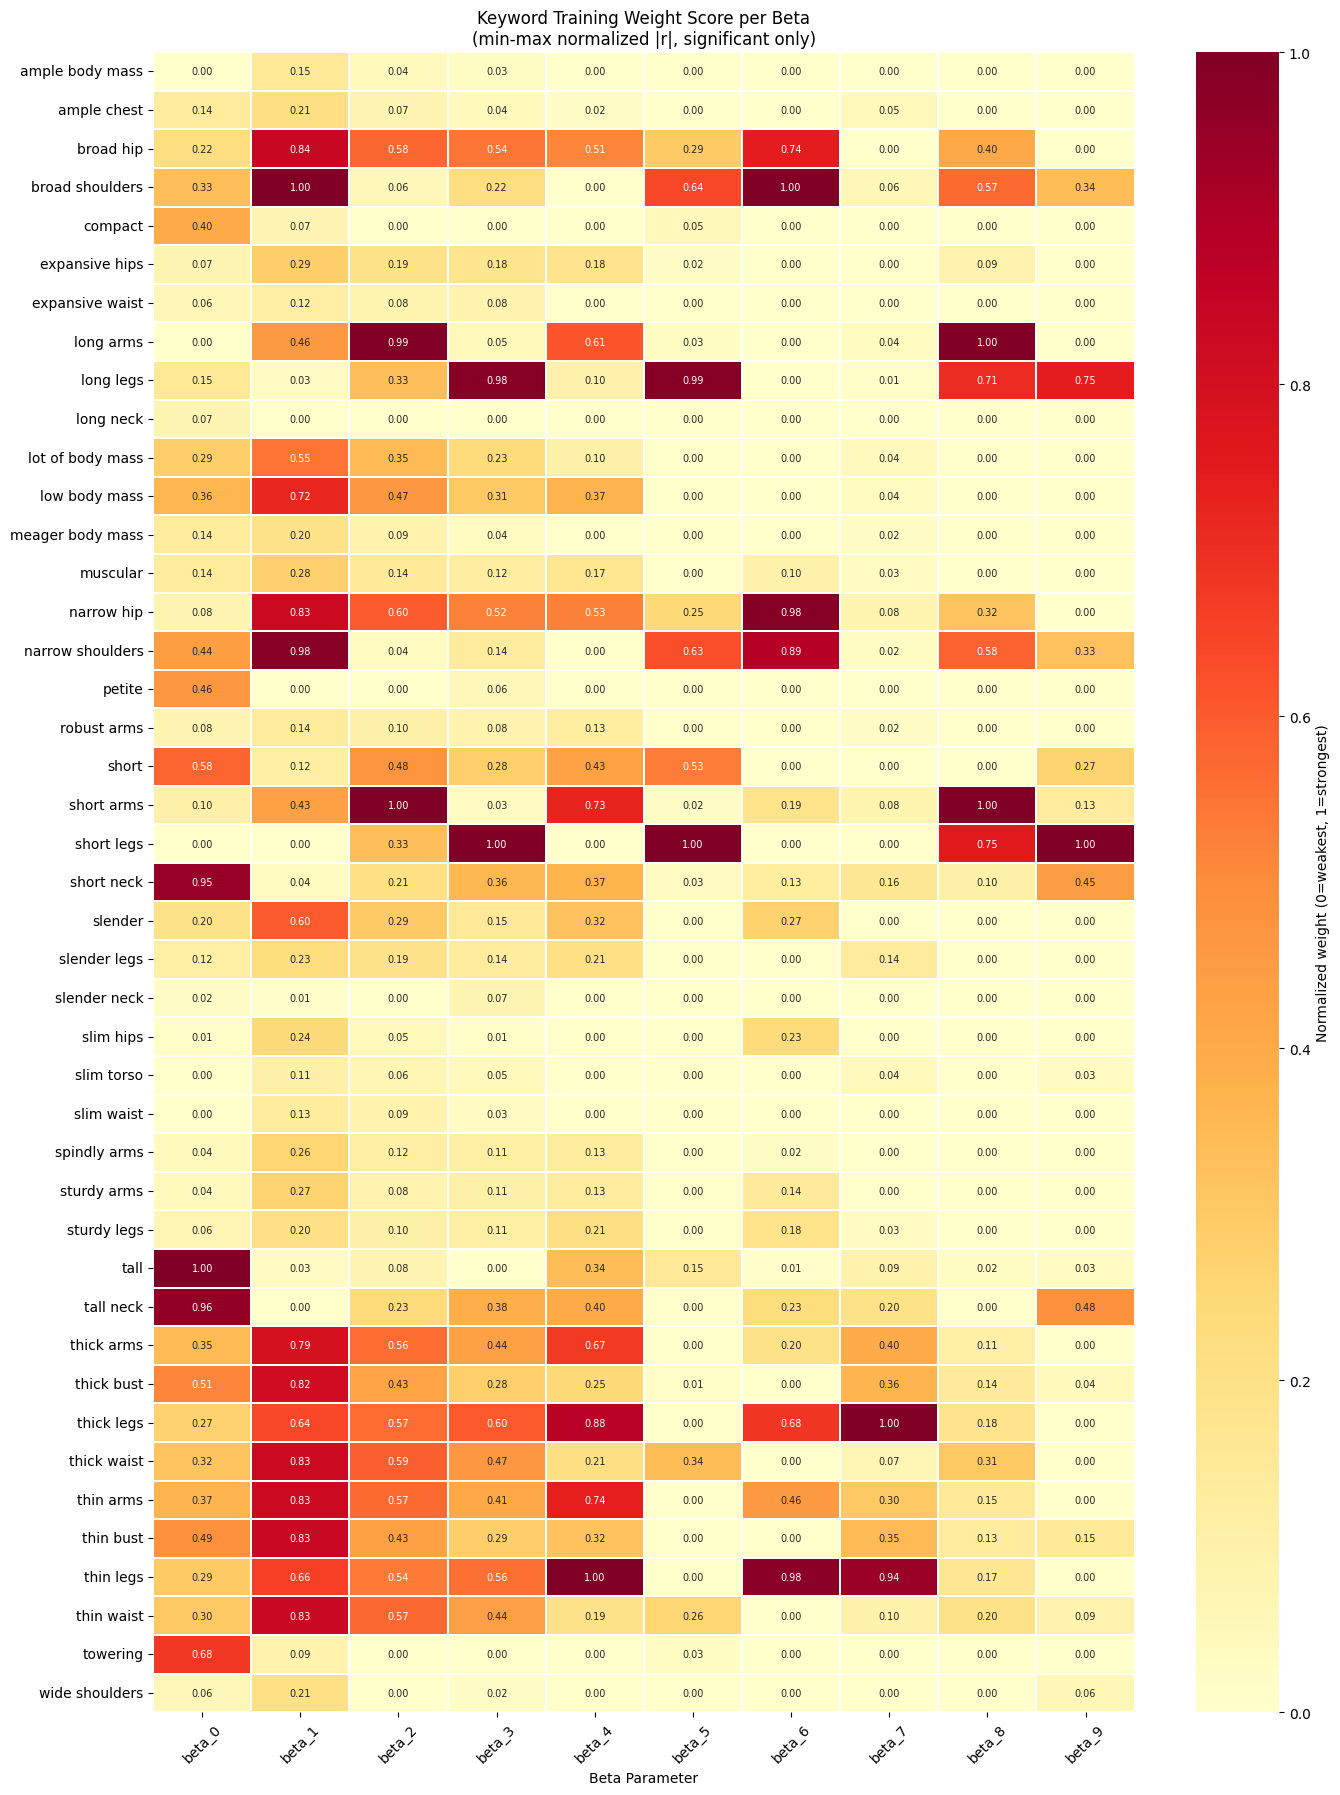

In [23]:
# Weight heatmap: keywords × betas (normalized weight, significant only)
weight_pivot = weight_df.pivot_table(
    index="keyword", columns="beta", values="weight", aggfunc="max"
)[ordered_cols].fillna(0)

fig, ax = plt.subplots(figsize=(14, max(6, len(weight_pivot) * 0.42)))
sns.heatmap(
    weight_pivot,
    cmap="YlOrRd",
    vmin=0, vmax=1,
    annot=True, fmt=".2f",
    annot_kws={"size": 7},
    linewidths=0.3,
    ax=ax,
    cbar_kws={"label": "Normalized weight (0=weakest, 1=strongest)"},
)
ax.set_title("Keyword Training Weight Score per Beta\n(min-max normalized |r|, significant only)", fontsize=12)
ax.set_xlabel("Beta Parameter")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

In [24]:
# ── Per-beta dominant keyword assignment ──────────────────────────────────────
# For each keyword, assign it to the beta where its weight is highest.
# This gives a "primary beta" per keyword — useful for constructing loss masks.

dominant = (
    weight_df
    .sort_values("weight", ascending=False)
    .drop_duplicates("keyword")   # keep best beta per keyword
    [["keyword", "beta", "r", "abs_r", "weight"]]
    .rename(columns={"beta": "primary_beta", "weight": "primary_weight"})
    .sort_values(["primary_beta", "primary_weight"], ascending=[True, False])
    .reset_index(drop=True)
)

print("=== Primary beta assignment per keyword ===")
dominant

=== Primary beta assignment per keyword ===


,keyword,primary_beta,r,abs_r,primary_weight
0,tall,beta_0,0.49349,0.49349,1.0000
1,tall neck,beta_0,0.47430,0.47430,0.9594
2,short neck,beta_0,-0.46997,0.46997,0.9502
3,towering,beta_0,0.34164,0.34164,0.6787
4,short,beta_0,-0.29448,0.29448,0.5790
5,petite,beta_0,-0.23900,0.23900,0.4616
6,compact,beta_0,-0.20750,0.20750,0.3950
7,long neck,beta_0,0.05528,0.05528,0.0729
8,broad shoulders,beta_1,0.43425,0.43425,1.0000
9,narrow shoulders,beta_1,-0.42766,0.42766,0.9842


## 8. Export Correlation Summary Table

Save results to CSV files for use during training configuration.

In [25]:
import os
OUT_DIR = os.path.dirname(os.path.abspath("body_shape_analysis.ipynb"))

# 1. Full correlation table
full_path = os.path.join(OUT_DIR, "keyword_beta_weights.csv")
corr_df.to_csv(full_path, index=False)
print(f"Saved full correlation table → {full_path}")

# 2. Pivot table  (keywords as rows, beta_0..beta_9 as columns)
pivot_path = os.path.join(OUT_DIR, "keyword_beta_pivot.csv")
r_pivot[ordered_cols].to_csv(pivot_path)
print(f"Saved pivot table            → {pivot_path}")

# 3. Normalized weight table
weight_path = os.path.join(OUT_DIR, "keyword_beta_weights_normalized.csv")
weight_pivot.to_csv(weight_path)
print(f"Saved normalized weights     → {weight_path}")

# 4. Primary-beta assignment (one row per keyword)
dominant_path = os.path.join(OUT_DIR, "keyword_primary_beta.csv")
dominant.to_csv(dominant_path, index=False)
print(f"Saved primary-beta table     → {dominant_path}")

# Preview normalized weight pivot
print()
weight_pivot.round(3)

Saved full correlation table → /home/schaeffler-pte-ltd/david_ws/BodyShapeGPT/scripts/keyword_beta_weights.csv
Saved pivot table            → /home/schaeffler-pte-ltd/david_ws/BodyShapeGPT/scripts/keyword_beta_pivot.csv
Saved normalized weights     → /home/schaeffler-pte-ltd/david_ws/BodyShapeGPT/scripts/keyword_beta_weights_normalized.csv
Saved primary-beta table     → /home/schaeffler-pte-ltd/david_ws/BodyShapeGPT/scripts/keyword_primary_beta.csv



beta,beta_0,beta_1,beta_2,beta_3,beta_4,beta_5,beta_6,beta_7,beta_8,beta_9
keyword,,,,,,,,,,
ample body mass,0.000,0.153,0.045,0.026,0.000,0.000,0.000,0.000,0.000,0.000
ample chest,0.137,0.214,0.075,0.044,0.022,0.000,0.000,0.048,0.000,0.000
broad hip,0.223,0.840,0.577,0.544,0.514,0.293,0.744,0.001,0.404,0.000
broad shoulders,0.332,1.000,0.058,0.219,0.000,0.638,1.000,0.059,0.570,0.341
compact,0.395,0.075,0.002,0.000,0.000,0.051,0.000,0.000,0.000,0.000
expansive hips,0.072,0.289,0.191,0.179,0.181,0.018,0.000,0.000,0.086,0.000
expansive waist,0.062,0.121,0.081,0.082,0.000,0.000,0.000,0.000,0.000,0.000
long arms,0.000,0.459,0.992,0.048,0.613,0.027,0.000,0.036,1.000,0.000
long legs,0.154,0.034,0.334,0.985,0.097,0.985,0.000,0.014,0.706,0.746


---
## How to Use These Results for Training

| Output file | Purpose |
|---|---|
| `keyword_beta_weights.csv` | Full (keyword, beta, r, p, weight) table — use to filter or threshold |
| `keyword_beta_pivot.csv` | Raw Pearson r pivot — inspect sign and magnitude per cell |
| `keyword_beta_weights_normalized.csv` | Weight score 0→1 per (keyword, beta) — directly usable as loss weights |
| `keyword_primary_beta.csv` | Which single beta each keyword drives most — for regression target selection |

### Suggested training strategy

1. **Keyword → beta target mapping**: use `keyword_primary_beta.csv` to know which beta output node each input keyword should supervise.
2. **Per-sample loss weighting**: for a description containing keyword *k*, up-weight the MSE loss on `primary_beta` by `primary_weight` (0–1 score).
3. **Beta learnability check**: betas where no keyword reaches `weight ≥ 0.5` (e.g. beta_6) may need richer annotations or can be excluded from text-supervised loss.
4. **Sanity check signs**: `r > 0` means the keyword predicts *higher* beta values; `r < 0` means *lower* — ensure your model output convention matches.